# Part 5 – Normalization / Feature Scaling + Random Forest Scaling Decision

## Member Information
**Member:** Weerarathna N.H  
**IT Number:** IT25103014  
**Individual Contribution:** Normalization / Feature Scaling + Random Forest Scaling Decision  

---

## Contribution Objective
Empirically demonstrate the mathematical transformation and practical effect of continuous feature scaling using Scikit-Learn `StandardScaler`, compare raw vs standardized distributions, and provide a formal algorithmic justification for deliberately excluding scaling from the final Random Forest preprocessing pipeline.


## Common Pipeline Prerequisites
### Shared group setup – not this member's individual contribution

The following setup represents shared group data loading, cleaning, target encoding, and train/test splitting.


In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Set consistent plotting styles
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'

# Define directory paths
DATA_RAW_PATH = Path('../data/raw/adult.csv')
OUTPUT_FIGURES_DIR = Path('../results/eda_visualizations')
os.makedirs(OUTPUT_FIGURES_DIR, exist_ok=True)

# 1. Load Raw Dataset
df_raw = pd.read_csv(DATA_RAW_PATH)
df = df_raw.copy()

# 2. Strip string whitespace & replace '?' with np.nan
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].astype(str).str.strip()
df.replace('?', np.nan, inplace=True)

# 3. Drop exact duplicates (24 rows) & remove redundant 'education'
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df.drop(columns=['education'], inplace=True)

# 4. Target variable encoding
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

# 5. Separate features and target
X = df.drop(columns=['income'])
y = df['income']

# 6. Stratified Train/Test Split (80/20) executed BEFORE fitting scaler
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print(f"X_train ready: {X_train.shape[0]:,} rows, X_test ready: {X_test.shape[0]:,} rows.")


X_train ready: 26,029 rows, X_test ready: 6,508 rows.


# Individual Contribution
## Feature Scaling Demonstration (StandardScaler) & Random Forest Architecture Decision
**Contributor:** Weerarathna N.H | IT25103014


### 1. StandardScaler Demonstration Setup
We demonstrate `StandardScaler` across four numerical features with diverse measurement scales:
- `age` (Years: 17 to 90)
- `fnlwgt` (Population weight: ~12,000 to 1,484,705)
- `education.num` (Educational years: 1 to 16)
- `hours.per.week` (Hours worked: 1 to 99)

> **Data Leakage Safeguard:**
> `StandardScaler` is fitted **strictly on `X_train`**, and applied to `X_test` without refitting.
> Original `X_train` and `X_test` dataframes are preserved completely untouched; scaled outputs are stored in dedicated demo variables.


In [ ]:
scaling_demo_features = ['age', 'fnlwgt', 'education.num', 'hours.per.week']

# 1. Initialize StandardScaler
scaler = StandardScaler()

# 2. Fit strictly on X_train only to prevent data leakage
scaler.fit(X_train[scaling_demo_features])

# 3. Transform X_train and X_test into dedicated demo variables
X_train_scaled_demo = pd.DataFrame(
    scaler.transform(X_train[scaling_demo_features]),
    columns=[f"{col}_scaled" for col in scaling_demo_features],
    index=X_train.index
)

X_test_scaled_demo = pd.DataFrame(
    scaler.transform(X_test[scaling_demo_features]),
    columns=[f"{col}_scaled" for col in scaling_demo_features],
    index=X_test.index
)

print("StandardScaler fitted strictly on X_train (Data Leakage avoided).")
print(f"X_train_scaled_demo shape: {X_train_scaled_demo.shape}")
print(f"X_test_scaled_demo shape:  {X_test_scaled_demo.shape}\n")

# Display learned mean and standard deviation
scaler_params_df = pd.DataFrame({
    'Feature': scaling_demo_features,
    'Train Mean (μ)': [f"{m:,.2f}" for m in scaler.mean_],
    'Train Std Dev (σ)': [f"{s:,.2f}" for s in scaler.scale_]
})
print("=== StandardScaler Parameters Learned from X_train ===")
display(scaler_params_df)


StandardScaler fitted strictly on X_train (Data Leakage avoided).
X_train_scaled_demo shape: (26029, 4)
X_test_scaled_demo shape:  (6508, 4)

=== StandardScaler Parameters Learned from X_train ===


,Feature,Train Mean (μ),Train Std Dev (σ)
0,age,38.50,13.62
1,fnlwgt,"189,830.01","105,854.45"
2,education.num,10.08,2.57
3,hours.per.week,40.44,12.29


### 2. Before vs After Scaling Comparison Table
Compare the original raw values against standardized z-scores for the first 5 samples in `X_train`.


In [ ]:
comparison_records = []
for i in range(5):
    idx = X_train.index[i]
    record = {'Sample': f"Sample #{i+1} (Row {idx})"}
    for feat in scaling_demo_features:
        raw_val = X_train.loc[idx, feat]
        scaled_val = X_train_scaled_demo.loc[idx, f"{feat}_scaled"]
        record[f"{feat} [Raw]"] = f"{raw_val:,.1f}"
        record[f"{feat} [Scaled]"] = f"{scaled_val:+.4f}"
    comparison_records.append(record)

comparison_df = pd.DataFrame(comparison_records)
print("=== Before vs After Scaling Comparison (First 5 Rows of X_train) ===")
display(comparison_df)


=== Before vs After Scaling Comparison (First 5 Rows of X_train) ===


,Sample,age [Raw],age [Scaled],fnlwgt [Raw],fnlwgt [Scaled],education.num [Raw],education.num [Scaled],hours.per.week [Raw],hours.per.week [Scaled]
0,Sample #1 (Row 25252),21.0,-1.2851,"140,012.0",-0.4706,10.0,-0.0311,20.0,-1.6635
1,Sample #2 (Row 3349),41.0,+0.1833,"433,989.0",+2.3066,11.0,+0.3576,60.0,+1.5920
2,Sample #3 (Row 4584),24.0,-1.0649,"241,951.0",+0.4924,9.0,-0.4198,40.0,-0.0357
3,Sample #4 (Row 7003),59.0,+1.5048,"99,131.0",-0.8568,9.0,-0.4198,18.0,-1.8262
4,Sample #5 (Row 882),35.0,-0.2573,"267,866.0",+0.7372,9.0,-0.4198,50.0,+0.7782


### 3. Before vs After Scaling Visualization (Boxplots)
Compare raw feature distributions against standardized distributions. On the training partition, StandardScaler centers and rescales each selected feature. A positive linear transformation preserves ordering and overall boxplot shape, while numerical quartile values and cross-feature distances change.


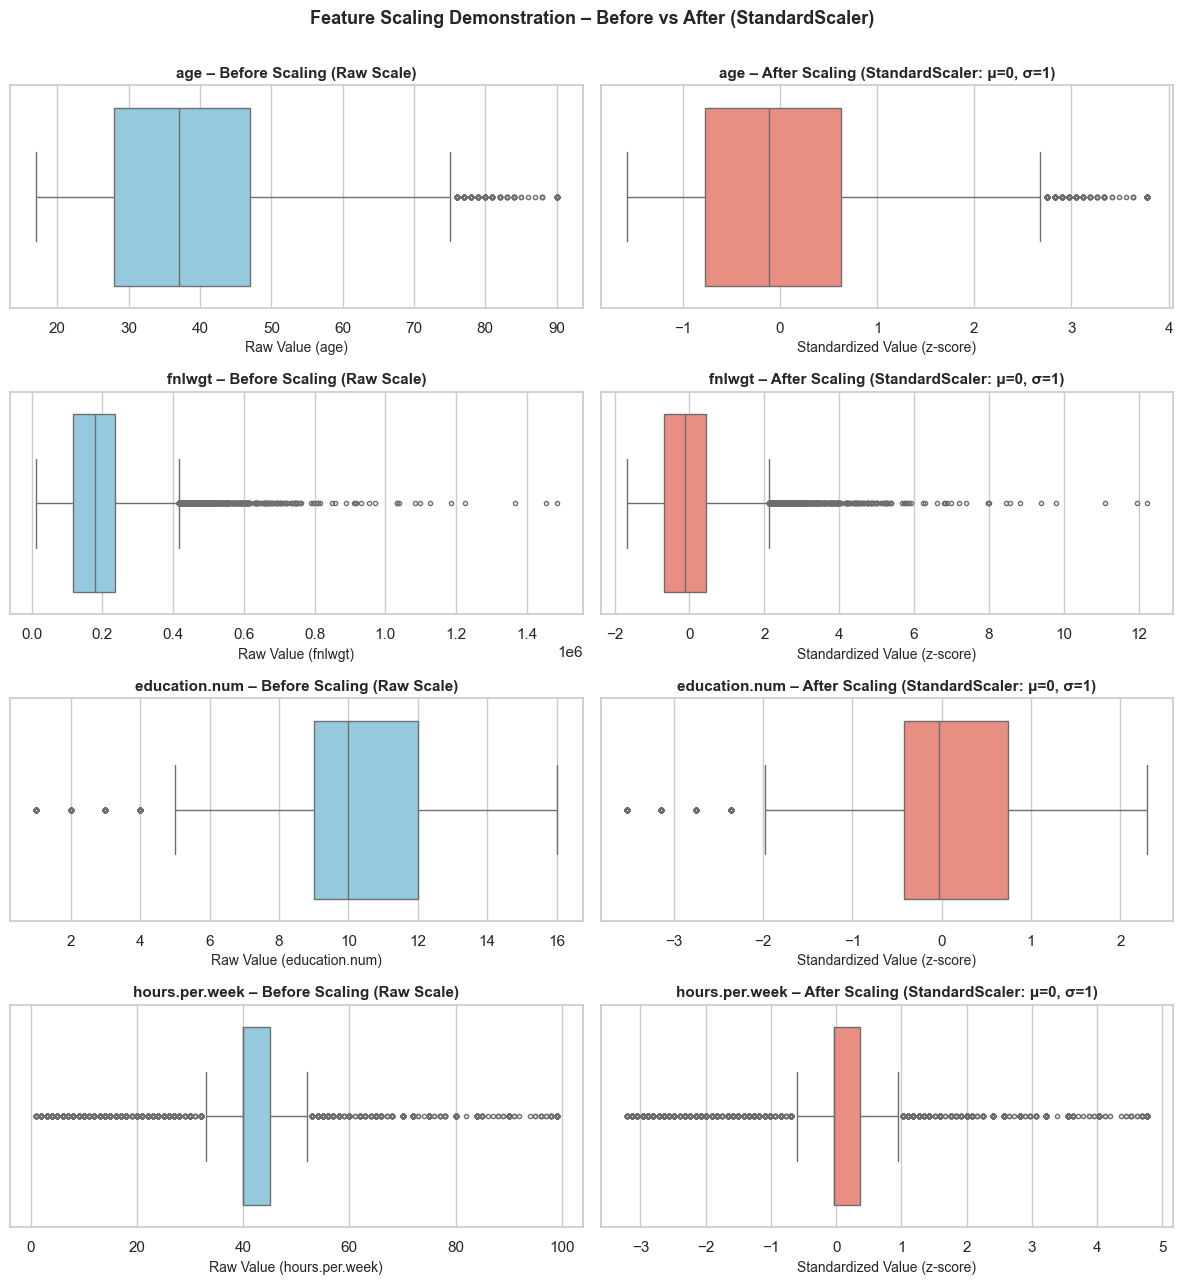

Saved figure: C:\Users\Malan\Downloads\2026-Y2-S1-MLB-B1G1-07\results\eda_visualizations\IT25103014_Scaling_Demonstration.png


In [ ]:
fig, axes = plt.subplots(
    nrows=len(scaling_demo_features),
    ncols=2,
    figsize=(12, 3.2 * len(scaling_demo_features))
)

for i, col in enumerate(scaling_demo_features):
    scaled_col = f"{col}_scaled"
    
    # Left: Original Raw Scale
    sns.boxplot(
        data=X_train,
        x=col,
        ax=axes[i, 0],
        color='skyblue',
        fliersize=3
    )
    axes[i, 0].set_title(f'{col} – Before Scaling (Raw Scale)', fontsize=11, fontweight='bold')
    axes[i, 0].set_xlabel(f'Raw Value ({col})', fontsize=10)
    
    # Right: Standardized z-score Scale
    sns.boxplot(
        data=X_train_scaled_demo,
        x=scaled_col,
        ax=axes[i, 1],
        color='salmon',
        fliersize=3
    )
    axes[i, 1].set_title(f'{col} – After Scaling (StandardScaler: μ=0, σ=1)', fontsize=11, fontweight='bold')
    axes[i, 1].set_xlabel('Standardized Value (z-score)', fontsize=10)

plt.suptitle('Feature Scaling Demonstration – Before vs After (StandardScaler)', fontsize=13, fontweight='bold', y=1.002)
plt.tight_layout()
FIGURE_PATH = OUTPUT_FIGURES_DIR / 'IT25103014_Scaling_Demonstration.png'
plt.savefig(FIGURE_PATH, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved figure: {FIGURE_PATH.resolve()}")


### 4. Final Numerical Preprocessing Pipeline Verification
Demonstrate the actual Scikit-Learn numerical pipeline constructed for Random Forest modeling.
Confirm that `StandardScaler` is **omitted** and that only `SimpleImputer(strategy="median")` is present.


In [ ]:
num_features_all = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Final Numerical Pipeline for Random Forest
numerical_pipeline_final = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

print("=== Final Random Forest Numerical Pipeline Architecture ===")
print(numerical_pipeline_final)
print(f"\nPipeline Steps: {[step[0] for step in numerical_pipeline_final.steps]}")
print(f"SimpleImputer configured: {isinstance(numerical_pipeline_final.named_steps['imputer'], SimpleImputer)}")
print(f"StandardScaler in Pipeline: {'scaler' in numerical_pipeline_final.named_steps}")

# Explicit assertion
assert 'scaler' not in numerical_pipeline_final.named_steps, "Error: StandardScaler must NOT be in the Random Forest numerical pipeline!"
print("\nVerification PASSED: StandardScaler is intentionally EXCLUDED from the final numerical pipeline.")


=== Final Random Forest Numerical Pipeline Architecture ===
Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])

Pipeline Steps: ['imputer']
SimpleImputer configured: True
StandardScaler in Pipeline: False

Verification PASSED: StandardScaler is intentionally EXCLUDED from the final numerical pipeline.
